# Exploratory Data Analysis (EDA) - Diabetes Prediction

## Objective
Understand the dataset, identify data quality issues, and uncover patterns related to diabetes risk factors.

## Dataset
Diabetes Prediction Dataset with 100,000 patient records and 9 features.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.colors import LinearSegmentedColormap
import warnings
warnings.filterwarnings('ignore')

# Configure style
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('colorblind')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12

import os
os.makedirs('../reports/figures', exist_ok=True)

print('Libraries loaded successfully')

Libraries loaded successfully


## 1. Data Loading

In [2]:
df = pd.read_csv('../data/raw/diabetes-prediction-dataset.csv')
print(f'Dataset shape: {df.shape}')
print(f'\nFirst 5 rows:')
df.head()

Dataset shape: (100000, 9)

First 5 rows:


,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes
0,Female,80.0,0,1,never,25.19,6.6,140,0
1,Female,54.0,0,0,No Info,27.32,6.6,80,0
2,Male,28.0,0,0,never,27.32,5.7,158,0
3,Female,36.0,0,0,current,23.45,5.0,155,0
4,Male,76.0,1,1,current,20.14,4.8,155,0


In [3]:
print('Data types:')
print(df.dtypes)
print(f'\nDataset info:')
df.info()

Data types:
gender                  object
age                    float64
hypertension             int64
heart_disease            int64
smoking_history         object
bmi                    float64
HbA1c_level            float64
blood_glucose_level      int64
diabetes                 int64
dtype: object

Dataset info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 9 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   gender               100000 non-null  object 
 1   age                  100000 non-null  float64
 2   hypertension         100000 non-null  int64  
 3   heart_disease        100000 non-null  int64  
 4   smoking_history      100000 non-null  object 
 5   bmi                  100000 non-null  float64
 6   HbA1c_level          100000 non-null  float64
 7   blood_glucose_level  100000 non-null  int64  
 8   diabetes             100000 non-null  int64  
dtypes: fl

## 2. Data Quality

In [4]:
# Missing values
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
print('Missing Values:')
print(missing_df[missing_df['Missing Count'] > 0])
if missing_df['Missing Count'].sum() == 0:
    print('No missing values found.')

Missing Values:
Empty DataFrame
Columns: [Missing Count, Missing %]
Index: []
No missing values found.


In [5]:
# Duplicate rows
duplicates = df.duplicated().sum()
print(f'Duplicate rows: {duplicates} ({duplicates/len(df)*100:.2f}%)')

Duplicate rows: 3854 (3.85%)


In [6]:
# Unique values per column
for col in df.columns:
    print(f'{col}: {df[col].nunique()} unique values')
    if df[col].nunique() < 20:
        print(f'  Values: {df[col].unique()}')

gender: 3 unique values
  Values: ['Female' 'Male' 'Other']
age: 102 unique values
hypertension: 2 unique values
  Values: [0 1]
heart_disease: 2 unique values
  Values: [1 0]
smoking_history: 6 unique values
  Values: ['never' 'No Info' 'current' 'former' 'ever' 'not current']
bmi: 4247 unique values
HbA1c_level: 18 unique values
  Values: [6.6 5.7 5.  4.8 6.5 6.1 6.  5.8 3.5 6.2 4.  4.5 9.  7.  8.8 8.2 7.5 6.8]
blood_glucose_level: 18 unique values
  Values: [140  80 158 155  85 200 145 100 130 160 126 159  90 260 220 300 280 240]
diabetes: 2 unique values
  Values: [0 1]


In [7]:
# Check for 'No Info' in smoking_history
print('Smoking history value counts:')
print(df['smoking_history'].value_counts())
print(f"\n'No Info' count: {(df['smoking_history'] == 'No Info').sum()} ({(df['smoking_history'] == 'No Info').mean()*100:.1f}%)")

Smoking history value counts:
smoking_history
No Info        35816
never          35095
former          9352
current         9286
not current     6447
ever            4004
Name: count, dtype: int64

'No Info' count: 35816 (35.8%)


In [8]:
# Gender distribution
print('Gender distribution:')
print(df['gender'].value_counts())

Gender distribution:
gender
Female    58552
Male      41430
Other        18
Name: count, dtype: int64


## 3. Univariate Analysis

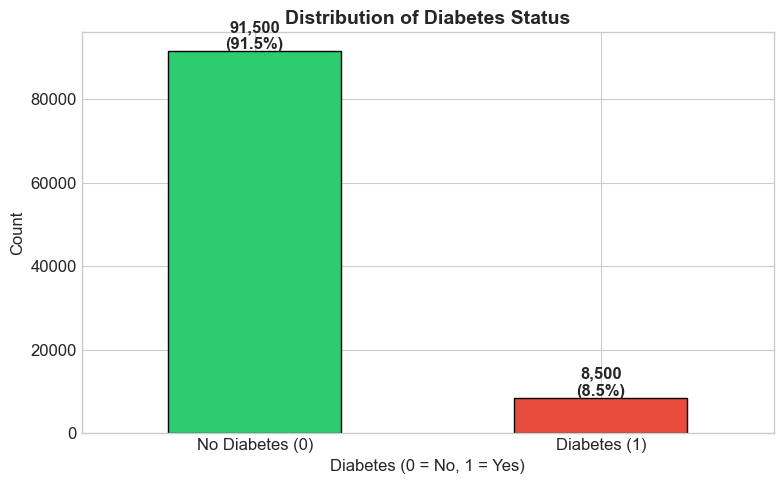

Chart 1: Target distribution saved.


In [9]:
# Chart 1: Target distribution (diabetes)
fig, ax = plt.subplots(figsize=(8, 5))
colors = ['#2ecc71', '#e74c3c']
df['diabetes'].value_counts().plot(kind='bar', color=colors, edgecolor='black', ax=ax)
ax.set_title('Distribution of Diabetes Status', fontsize=14, fontweight='bold')
ax.set_xlabel('Diabetes (0 = No, 1 = Yes)', fontsize=12)
ax.set_ylabel('Count', fontsize=12)
ax.set_xticklabels(['No Diabetes (0)', 'Diabetes (1)'], rotation=0)

for i, v in enumerate(df['diabetes'].value_counts()):
    ax.text(i, v + 500, f'{v:,}\n({v/len(df)*100:.1f}%)', ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig('../reports/figures/01_target_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print('Chart 1: Target distribution saved.')

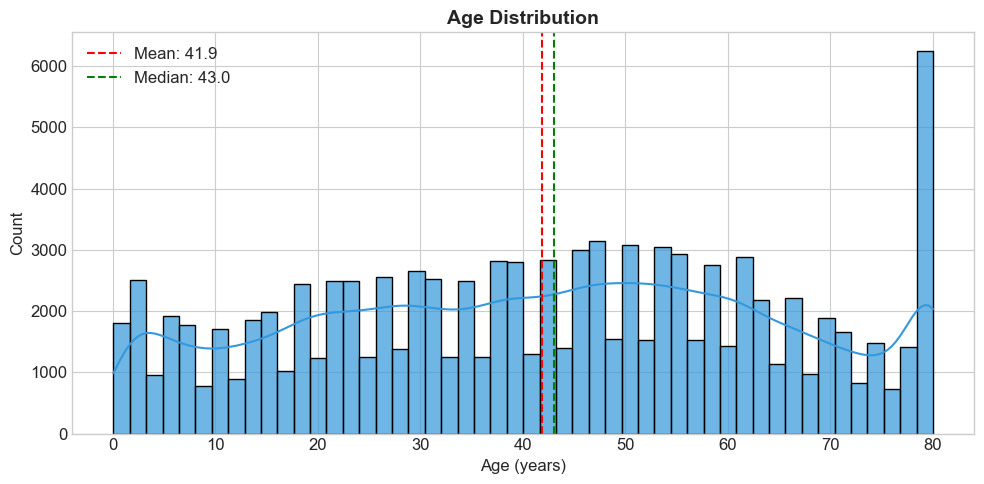

Chart 2: Age distribution. Mean: 41.9, Median: 43.0, Std: 22.5


In [10]:
# Chart 2: Age distribution
fig, ax = plt.subplots(figsize=(10, 5))
sns.histplot(data=df, x='age', bins=50, kde=True, color='#3498db', edgecolor='black', alpha=0.7, ax=ax)
ax.set_title('Age Distribution', fontsize=14, fontweight='bold')
ax.set_xlabel('Age (years)', fontsize=12)
ax.set_ylabel('Count', fontsize=12)
ax.axvline(df['age'].mean(), color='red', linestyle='--', label=f'Mean: {df["age"].mean():.1f}')
ax.axvline(df['age'].median(), color='green', linestyle='--', label=f'Median: {df["age"].median():.1f}')
ax.legend()
plt.tight_layout()
plt.savefig('../reports/figures/02_age_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Chart 2: Age distribution. Mean: {df["age"].mean():.1f}, Median: {df["age"].median():.1f}, Std: {df["age"].std():.1f}')

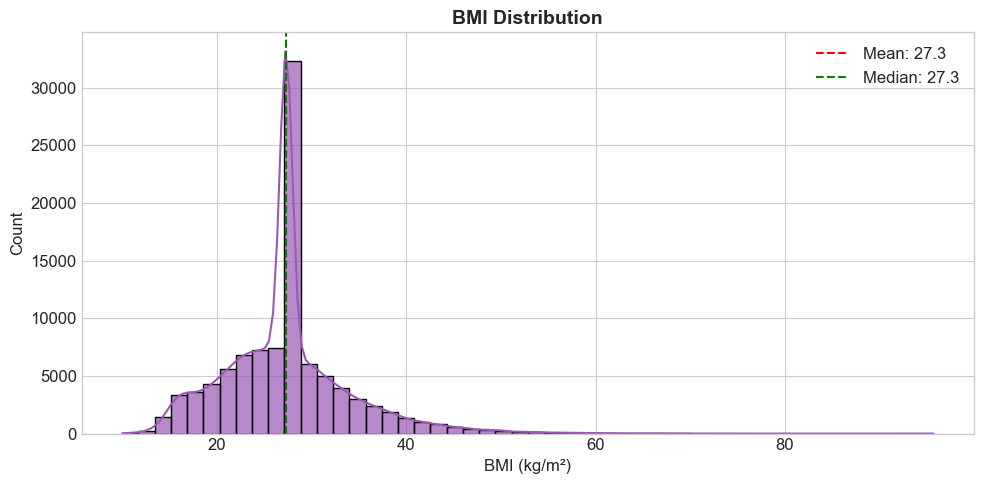

Chart 3: BMI distribution. Mean: 27.3, Std: 6.6


In [11]:
# Chart 3: BMI distribution
fig, ax = plt.subplots(figsize=(10, 5))
sns.histplot(data=df, x='bmi', bins=50, kde=True, color='#9b59b6', edgecolor='black', alpha=0.7, ax=ax)
ax.set_title('BMI Distribution', fontsize=14, fontweight='bold')
ax.set_xlabel('BMI (kg/m²)', fontsize=12)
ax.set_ylabel('Count', fontsize=12)
ax.axvline(df['bmi'].mean(), color='red', linestyle='--', label=f'Mean: {df["bmi"].mean():.1f}')
ax.axvline(df['bmi'].median(), color='green', linestyle='--', label=f'Median: {df["bmi"].median():.1f}')
ax.legend()
plt.tight_layout()
plt.savefig('../reports/figures/03_bmi_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Chart 3: BMI distribution. Mean: {df["bmi"].mean():.1f}, Std: {df["bmi"].std():.1f}')

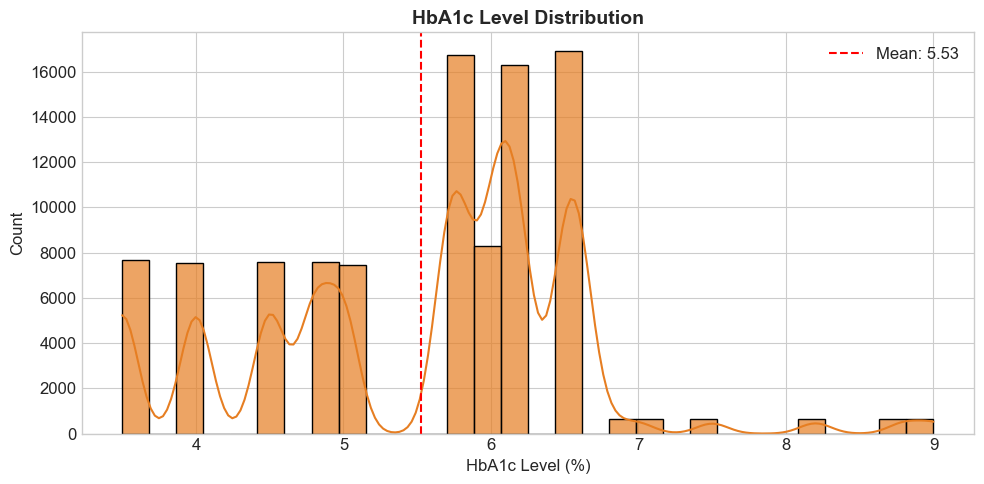

Chart 4: HbA1c distribution. Mean: 5.53, Std: 1.07


In [12]:
# Chart 4: HbA1c_level distribution
fig, ax = plt.subplots(figsize=(10, 5))
sns.histplot(data=df, x='HbA1c_level', bins=30, kde=True, color='#e67e22', edgecolor='black', alpha=0.7, ax=ax)
ax.set_title('HbA1c Level Distribution', fontsize=14, fontweight='bold')
ax.set_xlabel('HbA1c Level (%)', fontsize=12)
ax.set_ylabel('Count', fontsize=12)
ax.axvline(df['HbA1c_level'].mean(), color='red', linestyle='--', label=f'Mean: {df["HbA1c_level"].mean():.2f}')
ax.legend()
plt.tight_layout()
plt.savefig('../reports/figures/04_hba1c_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Chart 4: HbA1c distribution. Mean: {df["HbA1c_level"].mean():.2f}, Std: {df["HbA1c_level"].std():.2f}')

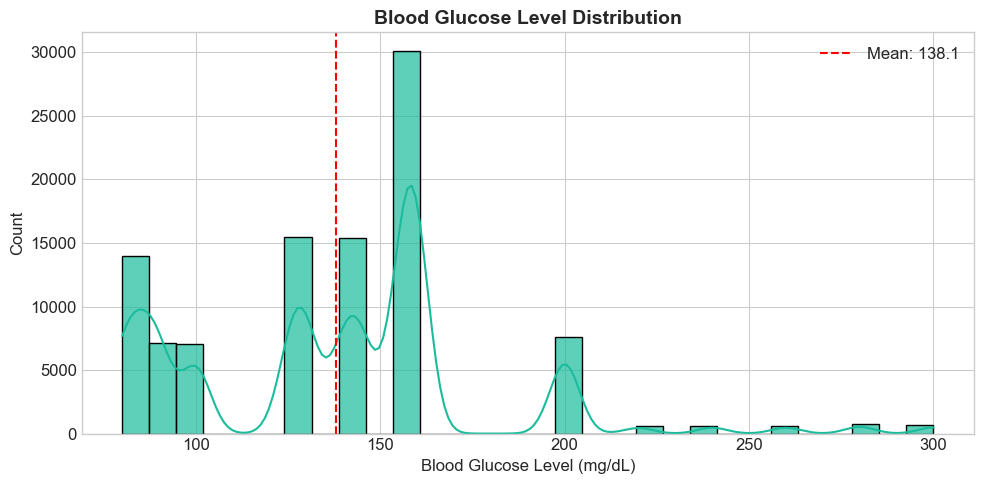

Chart 5: Blood glucose distribution. Mean: 138.1, Std: 40.7


In [13]:
# Chart 5: Blood glucose level distribution
fig, ax = plt.subplots(figsize=(10, 5))
sns.histplot(data=df, x='blood_glucose_level', bins=30, kde=True, color='#1abc9c', edgecolor='black', alpha=0.7, ax=ax)
ax.set_title('Blood Glucose Level Distribution', fontsize=14, fontweight='bold')
ax.set_xlabel('Blood Glucose Level (mg/dL)', fontsize=12)
ax.set_ylabel('Count', fontsize=12)
ax.axvline(df['blood_glucose_level'].mean(), color='red', linestyle='--', label=f'Mean: {df["blood_glucose_level"].mean():.1f}')
ax.legend()
plt.tight_layout()
plt.savefig('../reports/figures/05_glucose_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Chart 5: Blood glucose distribution. Mean: {df["blood_glucose_level"].mean():.1f}, Std: {df["blood_glucose_level"].std():.1f}')

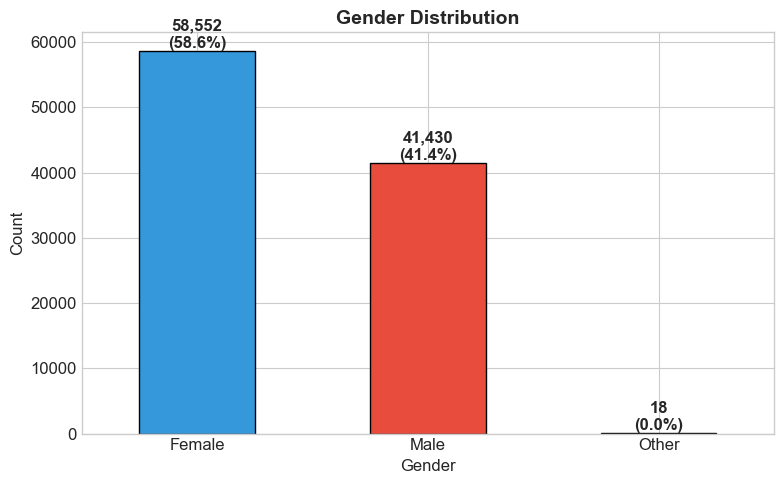

Chart 6: Gender distribution.


In [14]:
# Chart 6: Gender distribution
fig, ax = plt.subplots(figsize=(8, 5))
gender_counts = df['gender'].value_counts()
colors = ['#3498db', '#e74c3c', '#95a5a6']
gender_counts.plot(kind='bar', color=colors[:len(gender_counts)], edgecolor='black', ax=ax)
ax.set_title('Gender Distribution', fontsize=14, fontweight='bold')
ax.set_xlabel('Gender', fontsize=12)
ax.set_ylabel('Count', fontsize=12)
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
for i, v in enumerate(gender_counts.values):
    ax.text(i, v + 500, f'{v:,}\n({v/len(df)*100:.1f}%)', ha='center', fontweight='bold')
plt.tight_layout()
plt.savefig('../reports/figures/06_gender_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print('Chart 6: Gender distribution.')

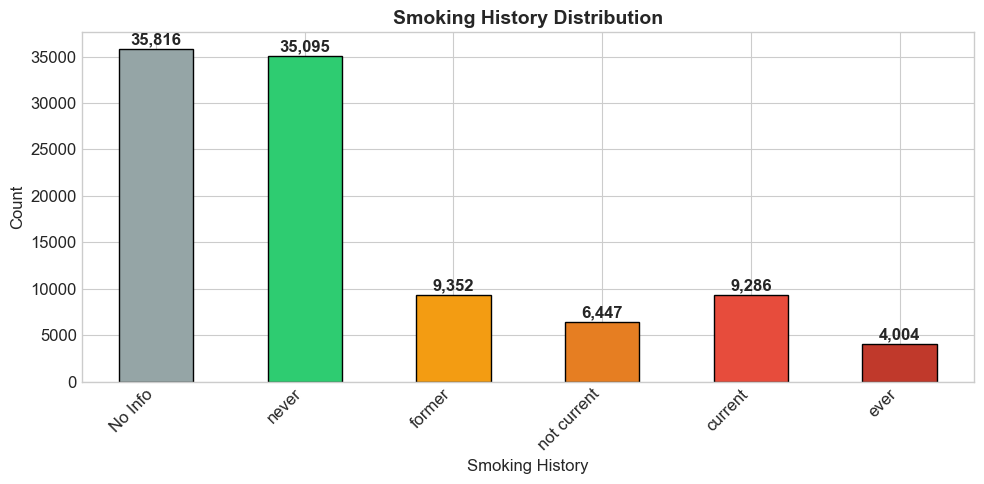

Chart 7: Smoking history distribution.


In [15]:
# Chart 7: Smoking history distribution
fig, ax = plt.subplots(figsize=(10, 5))
smoking_counts = df['smoking_history'].value_counts()
smoking_order = ['No Info', 'never', 'former', 'not current', 'current', 'ever']
smoking_counts = smoking_counts.reindex([x for x in smoking_order if x in smoking_counts.index])
colors = ['#95a5a6', '#2ecc71', '#f39c12', '#e67e22', '#e74c3c', '#c0392b']
smoking_counts.plot(kind='bar', color=colors[:len(smoking_counts)], edgecolor='black', ax=ax)
ax.set_title('Smoking History Distribution', fontsize=14, fontweight='bold')
ax.set_xlabel('Smoking History', fontsize=12)
ax.set_ylabel('Count', fontsize=12)
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
for i, v in enumerate(smoking_counts.values):
    ax.text(i, v + 500, f'{v:,}', ha='center', fontweight='bold')
plt.tight_layout()
plt.savefig('../reports/figures/07_smoking_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print('Chart 7: Smoking history distribution.')

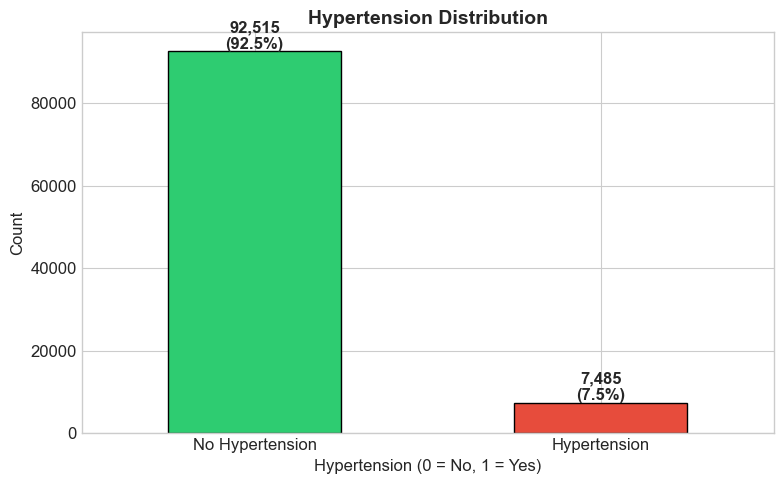

Chart 8: Hypertension distribution.


In [16]:
# Chart 8: Hypertension distribution
fig, ax = plt.subplots(figsize=(8, 5))
hyper_counts = df['hypertension'].value_counts()
colors = ['#2ecc71', '#e74c3c']
hyper_counts.plot(kind='bar', color=colors, edgecolor='black', ax=ax)
ax.set_title('Hypertension Distribution', fontsize=14, fontweight='bold')
ax.set_xlabel('Hypertension (0 = No, 1 = Yes)', fontsize=12)
ax.set_ylabel('Count', fontsize=12)
ax.set_xticklabels(['No Hypertension', 'Hypertension'], rotation=0)
for i, v in enumerate(hyper_counts.values):
    ax.text(i, v + 500, f'{v:,}\n({v/len(df)*100:.1f}%)', ha='center', fontweight='bold')
plt.tight_layout()
plt.savefig('../reports/figures/08_hypertension_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print('Chart 8: Hypertension distribution.')

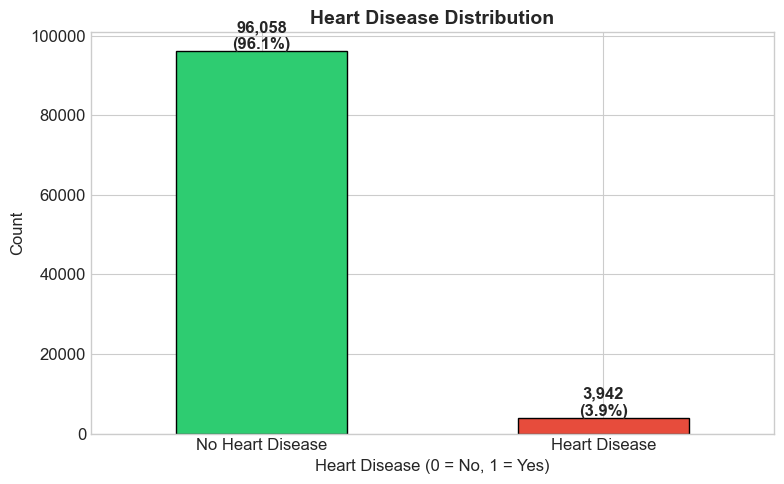

Chart 9: Heart disease distribution.


In [17]:
# Chart 9: Heart disease distribution
fig, ax = plt.subplots(figsize=(8, 5))
heart_counts = df['heart_disease'].value_counts()
colors = ['#2ecc71', '#e74c3c']
heart_counts.plot(kind='bar', color=colors, edgecolor='black', ax=ax)
ax.set_title('Heart Disease Distribution', fontsize=14, fontweight='bold')
ax.set_xlabel('Heart Disease (0 = No, 1 = Yes)', fontsize=12)
ax.set_ylabel('Count', fontsize=12)
ax.set_xticklabels(['No Heart Disease', 'Heart Disease'], rotation=0)
for i, v in enumerate(heart_counts.values):
    ax.text(i, v + 500, f'{v:,}\n({v/len(df)*100:.1f}%)', ha='center', fontweight='bold')
plt.tight_layout()
plt.savefig('../reports/figures/09_heart_disease_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print('Chart 9: Heart disease distribution.')

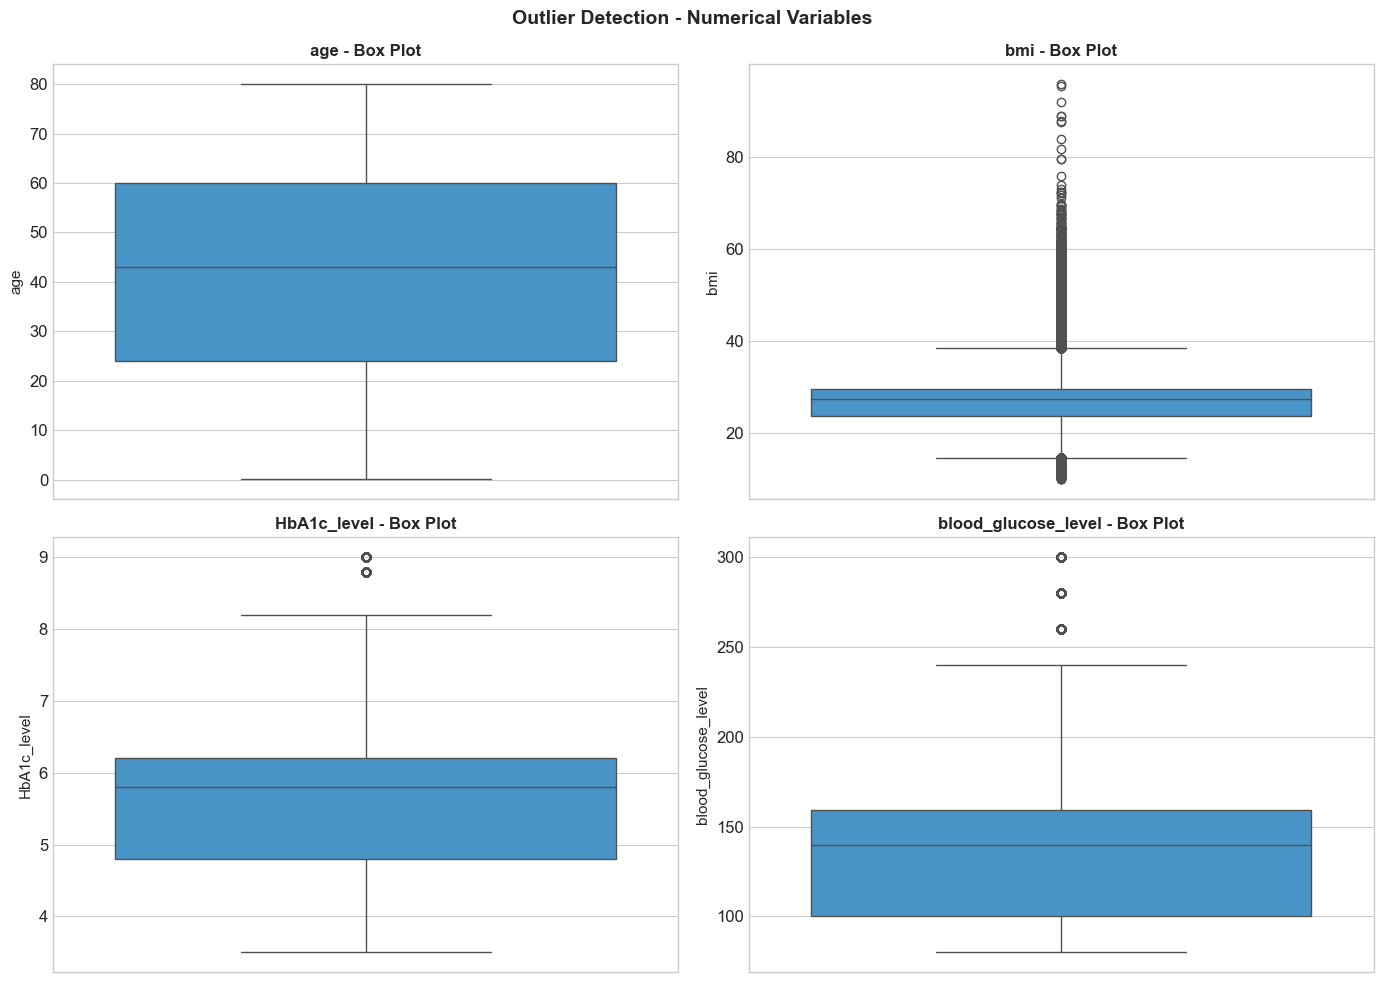

age: 0 outliers (0.00%)
bmi: 7086 outliers (7.09%)
HbA1c_level: 1315 outliers (1.31%)
blood_glucose_level: 2038 outliers (2.04%)


In [18]:
# Chart 10: Outlier detection - Box plots for numerical variables
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

numerical_cols = ['age', 'bmi', 'HbA1c_level', 'blood_glucose_level']
for idx, col in enumerate(numerical_cols):
    ax = axes[idx // 2, idx % 2]
    sns.boxplot(data=df, y=col, color='#3498db', ax=ax)
    ax.set_title(f'{col} - Box Plot', fontsize=12, fontweight='bold')
    ax.set_ylabel(col, fontsize=11)

plt.suptitle('Outlier Detection - Numerical Variables', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../reports/figures/10_outlier_detection.png', dpi=150, bbox_inches='tight')
plt.show()

# Report outlier counts using IQR
for col in numerical_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    outliers = ((df[col] < Q1 - 1.5 * IQR) | (df[col] > Q3 + 1.5 * IQR)).sum()
    print(f'{col}: {outliers} outliers ({outliers/len(df)*100:.2f}%)')

## 4. Bivariate Analysis vs Diabetes

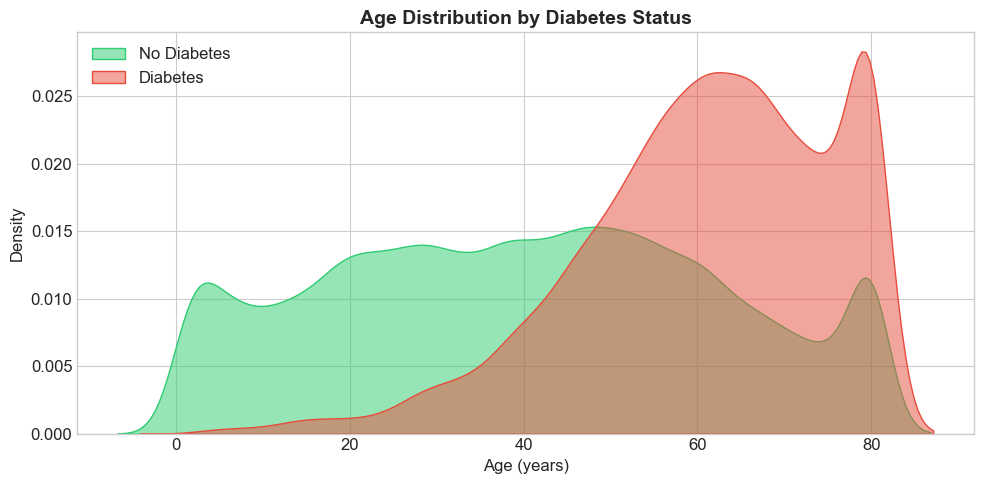

Chart 11: Older patients show higher diabetes prevalence.


In [19]:
# Chart 11: Age distribution by diabetes status (KDE)
fig, ax = plt.subplots(figsize=(10, 5))
for label, color in zip([0, 1], ['#2ecc71', '#e74c3c']):
    subset = df[df['diabetes'] == label]
    sns.kdeplot(data=subset, x='age', fill=True, alpha=0.5, color=color, 
                label=f'Diabetes = {label}', ax=ax)
ax.set_title('Age Distribution by Diabetes Status', fontsize=14, fontweight='bold')
ax.set_xlabel('Age (years)', fontsize=12)
ax.set_ylabel('Density', fontsize=12)
ax.legend(['No Diabetes', 'Diabetes'])
plt.tight_layout()
plt.savefig('../reports/figures/11_age_by_diabetes.png', dpi=150, bbox_inches='tight')
plt.show()
print('Chart 11: Older patients show higher diabetes prevalence.')

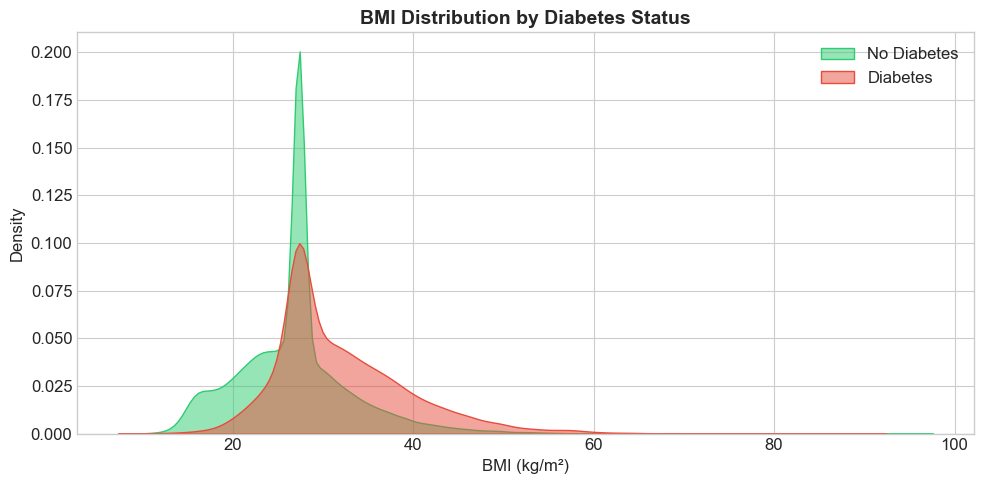

Chart 12: Diabetic patients tend to have higher BMI.


In [20]:
# Chart 12: BMI distribution by diabetes status (KDE)
fig, ax = plt.subplots(figsize=(10, 5))
for label, color in zip([0, 1], ['#2ecc71', '#e74c3c']):
    subset = df[df['diabetes'] == label]
    sns.kdeplot(data=subset, x='bmi', fill=True, alpha=0.5, color=color, 
                label=f'Diabetes = {label}', ax=ax)
ax.set_title('BMI Distribution by Diabetes Status', fontsize=14, fontweight='bold')
ax.set_xlabel('BMI (kg/m²)', fontsize=12)
ax.set_ylabel('Density', fontsize=12)
ax.legend(['No Diabetes', 'Diabetes'])
plt.tight_layout()
plt.savefig('../reports/figures/12_bmi_by_diabetes.png', dpi=150, bbox_inches='tight')
plt.show()
print('Chart 12: Diabetic patients tend to have higher BMI.')

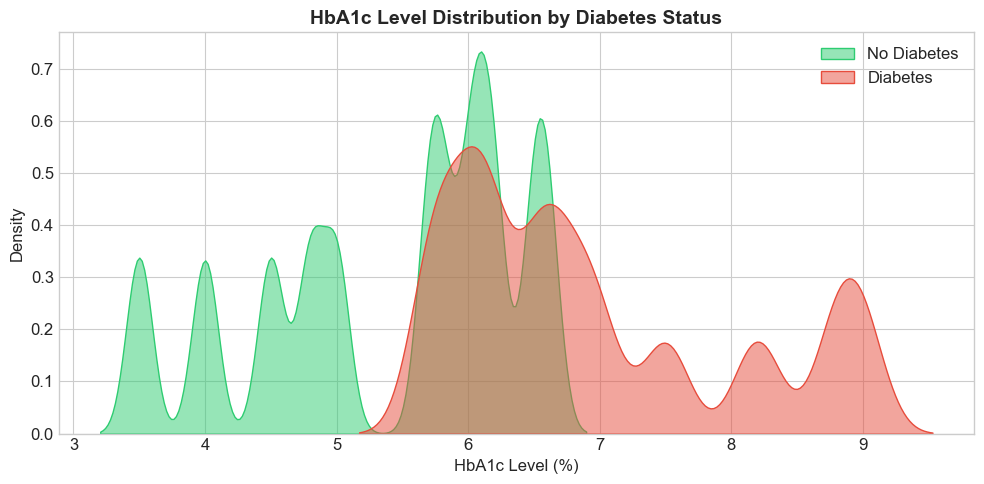

Chart 13: HbA1c shows clear separation between diabetic and non-diabetic patients.


In [21]:
# Chart 13: HbA1c level by diabetes status (KDE)
fig, ax = plt.subplots(figsize=(10, 5))
for label, color in zip([0, 1], ['#2ecc71', '#e74c3c']):
    subset = df[df['diabetes'] == label]
    sns.kdeplot(data=subset, x='HbA1c_level', fill=True, alpha=0.5, color=color, 
                label=f'Diabetes = {label}', ax=ax)
ax.set_title('HbA1c Level Distribution by Diabetes Status', fontsize=14, fontweight='bold')
ax.set_xlabel('HbA1c Level (%)', fontsize=12)
ax.set_ylabel('Density', fontsize=12)
ax.legend(['No Diabetes', 'Diabetes'])
plt.tight_layout()
plt.savefig('../reports/figures/13_hba1c_by_diabetes.png', dpi=150, bbox_inches='tight')
plt.show()
print('Chart 13: HbA1c shows clear separation between diabetic and non-diabetic patients.')

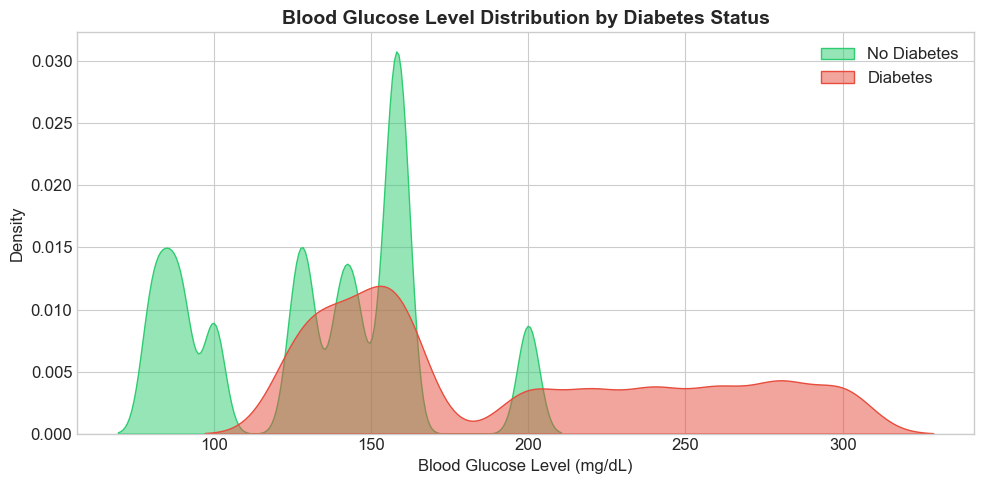

Chart 14: Blood glucose shows strong separation between groups.


In [22]:
# Chart 14: Blood glucose level by diabetes status (KDE)
fig, ax = plt.subplots(figsize=(10, 5))
for label, color in zip([0, 1], ['#2ecc71', '#e74c3c']):
    subset = df[df['diabetes'] == label]
    sns.kdeplot(data=subset, x='blood_glucose_level', fill=True, alpha=0.5, color=color, 
                label=f'Diabetes = {label}', ax=ax)
ax.set_title('Blood Glucose Level Distribution by Diabetes Status', fontsize=14, fontweight='bold')
ax.set_xlabel('Blood Glucose Level (mg/dL)', fontsize=12)
ax.set_ylabel('Density', fontsize=12)
ax.legend(['No Diabetes', 'Diabetes'])
plt.tight_layout()
plt.savefig('../reports/figures/14_glucose_by_diabetes.png', dpi=150, bbox_inches='tight')
plt.show()
print('Chart 14: Blood glucose shows strong separation between groups.')

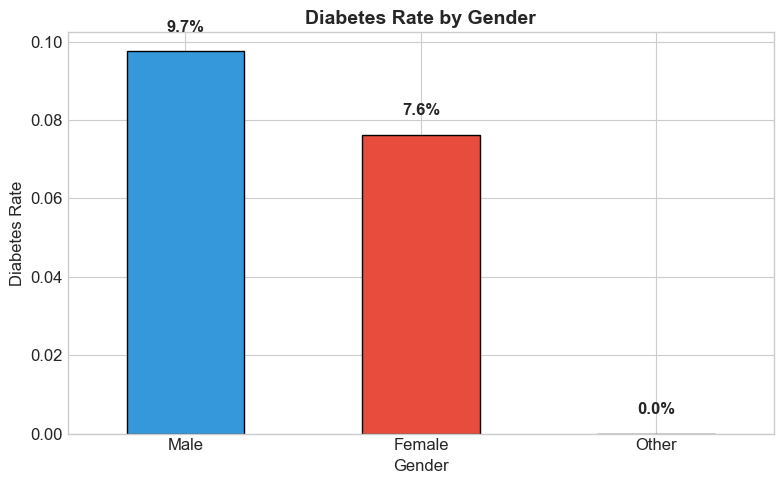

Chart 15: Diabetes rate by gender.


In [23]:
# Chart 15: Diabetes rate by gender
fig, ax = plt.subplots(figsize=(8, 5))
gender_diabetes = df.groupby('gender')['diabetes'].mean().sort_values(ascending=False)
colors = ['#3498db', '#e74c3c', '#95a5a6']
gender_diabetes.plot(kind='bar', color=colors[:len(gender_diabetes)], edgecolor='black', ax=ax)
ax.set_title('Diabetes Rate by Gender', fontsize=14, fontweight='bold')
ax.set_xlabel('Gender', fontsize=12)
ax.set_ylabel('Diabetes Rate', fontsize=12)
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
for i, v in enumerate(gender_diabetes.values):
    ax.text(i, v + 0.005, f'{v:.1%}', ha='center', fontweight='bold')
plt.tight_layout()
plt.savefig('../reports/figures/15_diabetes_by_gender.png', dpi=150, bbox_inches='tight')
plt.show()
print('Chart 15: Diabetes rate by gender.')

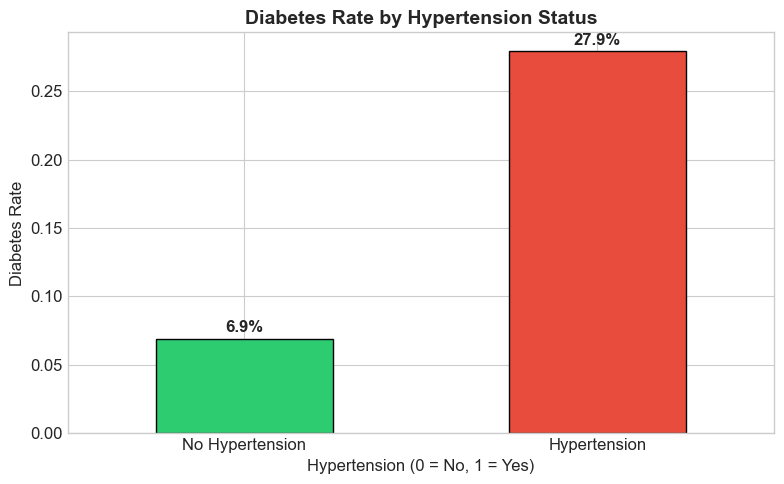

Chart 16: Patients with hypertension have significantly higher diabetes rate.


In [24]:
# Chart 16: Diabetes rate by hypertension
fig, ax = plt.subplots(figsize=(8, 5))
hyper_diabetes = df.groupby('hypertension')['diabetes'].mean()
colors = ['#2ecc71', '#e74c3c']
hyper_diabetes.plot(kind='bar', color=colors, edgecolor='black', ax=ax)
ax.set_title('Diabetes Rate by Hypertension Status', fontsize=14, fontweight='bold')
ax.set_xlabel('Hypertension (0 = No, 1 = Yes)', fontsize=12)
ax.set_ylabel('Diabetes Rate', fontsize=12)
ax.set_xticklabels(['No Hypertension', 'Hypertension'], rotation=0)
for i, v in enumerate(hyper_diabetes.values):
    ax.text(i, v + 0.005, f'{v:.1%}', ha='center', fontweight='bold')
plt.tight_layout()
plt.savefig('../reports/figures/16_diabetes_by_hypertension.png', dpi=150, bbox_inches='tight')
plt.show()
print('Chart 16: Patients with hypertension have significantly higher diabetes rate.')

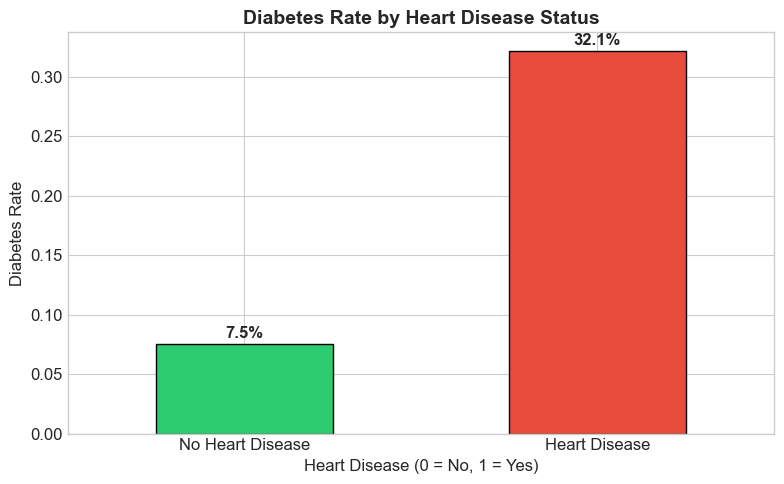

Chart 17: Patients with heart disease have higher diabetes rate.


In [25]:
# Chart 17: Diabetes rate by heart disease
fig, ax = plt.subplots(figsize=(8, 5))
heart_diabetes = df.groupby('heart_disease')['diabetes'].mean()
colors = ['#2ecc71', '#e74c3c']
heart_diabetes.plot(kind='bar', color=colors, edgecolor='black', ax=ax)
ax.set_title('Diabetes Rate by Heart Disease Status', fontsize=14, fontweight='bold')
ax.set_xlabel('Heart Disease (0 = No, 1 = Yes)', fontsize=12)
ax.set_ylabel('Diabetes Rate', fontsize=12)
ax.set_xticklabels(['No Heart Disease', 'Heart Disease'], rotation=0)
for i, v in enumerate(heart_diabetes.values):
    ax.text(i, v + 0.005, f'{v:.1%}', ha='center', fontweight='bold')
plt.tight_layout()
plt.savefig('../reports/figures/17_diabetes_by_heart_disease.png', dpi=150, bbox_inches='tight')
plt.show()
print('Chart 17: Patients with heart disease have higher diabetes rate.')

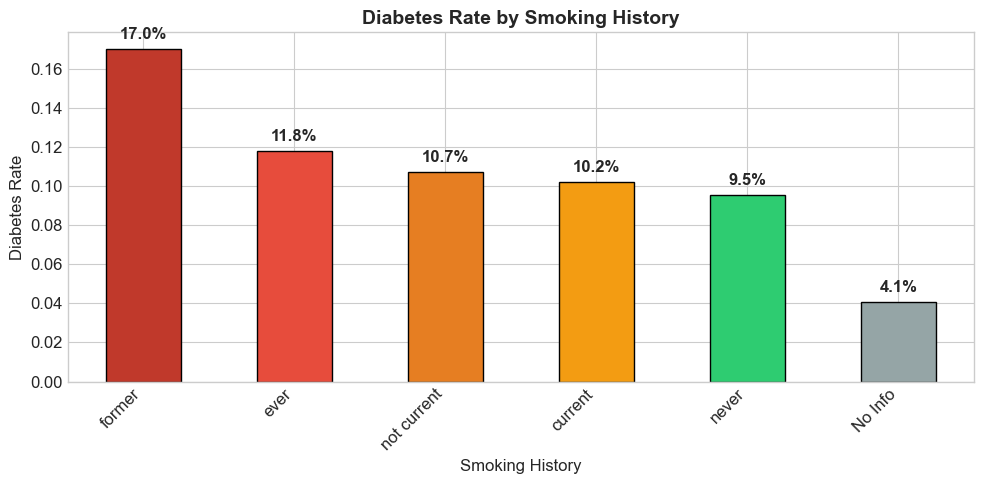

Chart 18: Smoking history shows varying diabetes rates across categories.


In [26]:
# Chart 18: Diabetes rate by smoking history
fig, ax = plt.subplots(figsize=(10, 5))
smoking_diabetes = df.groupby('smoking_history')['diabetes'].mean().sort_values(ascending=False)
colors = ['#c0392b', '#e74c3c', '#e67e22', '#f39c12', '#2ecc71', '#95a5a6']
smoking_diabetes.plot(kind='bar', color=colors[:len(smoking_diabetes)], edgecolor='black', ax=ax)
ax.set_title('Diabetes Rate by Smoking History', fontsize=14, fontweight='bold')
ax.set_xlabel('Smoking History', fontsize=12)
ax.set_ylabel('Diabetes Rate', fontsize=12)
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
for i, v in enumerate(smoking_diabetes.values):
    ax.text(i, v + 0.005, f'{v:.1%}', ha='center', fontweight='bold')
plt.tight_layout()
plt.savefig('../reports/figures/18_diabetes_by_smoking.png', dpi=150, bbox_inches='tight')
plt.show()
print('Chart 18: Smoking history shows varying diabetes rates across categories.')

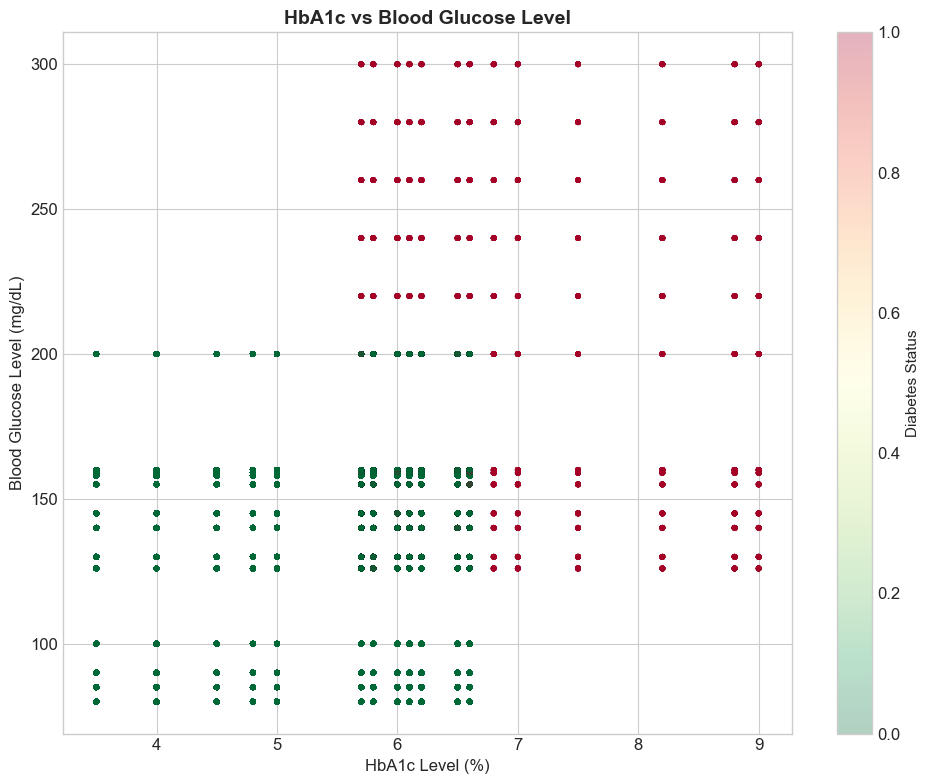

Chart 19: Higher HbA1c and glucose levels cluster with diabetes cases.


In [27]:
# Chart 19: HbA1c vs Blood Glucose colored by diabetes
fig, ax = plt.subplots(figsize=(10, 8))
scatter = ax.scatter(df['HbA1c_level'], df['blood_glucose_level'], 
                     c=df['diabetes'], cmap='RdYlGn_r', alpha=0.3, s=10)
ax.set_title('HbA1c vs Blood Glucose Level', fontsize=14, fontweight='bold')
ax.set_xlabel('HbA1c Level (%)', fontsize=12)
ax.set_ylabel('Blood Glucose Level (mg/dL)', fontsize=12)
cbar = plt.colorbar(scatter, ax=ax)
cbar.set_label('Diabetes Status', fontsize=11)
plt.tight_layout()
plt.savefig('../reports/figures/19_hba1c_vs_glucose.png', dpi=150, bbox_inches='tight')
plt.show()
print('Chart 19: Higher HbA1c and glucose levels cluster with diabetes cases.')

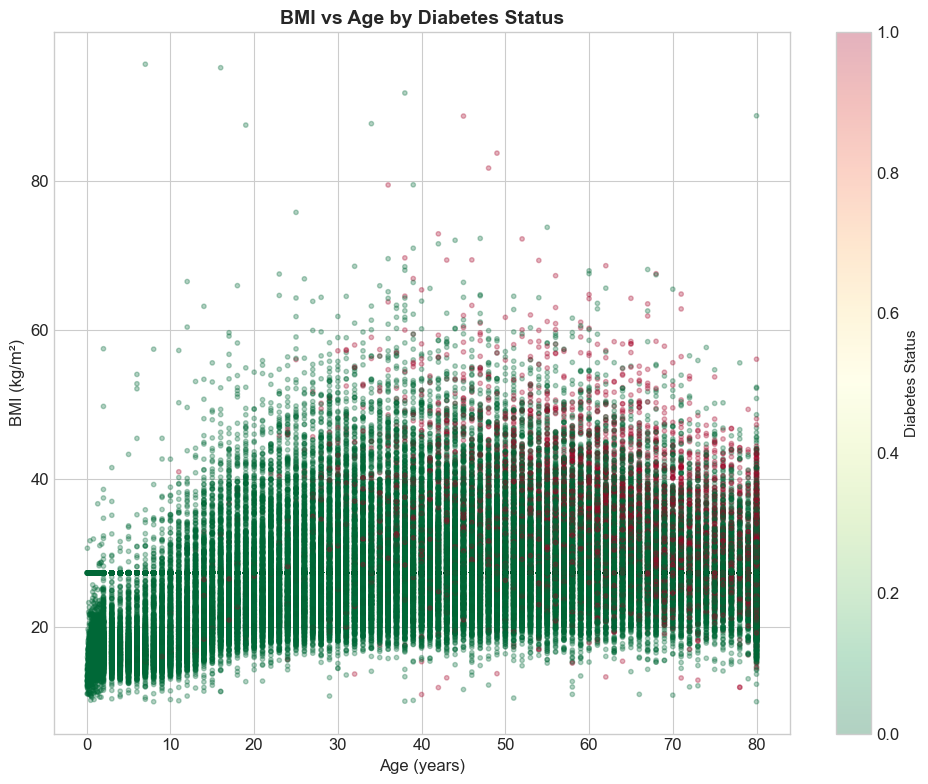

Chart 20: Older age and higher BMI correlate with diabetes.


In [28]:
# Chart 20: BMI vs Age colored by diabetes
fig, ax = plt.subplots(figsize=(10, 8))
scatter = ax.scatter(df['age'], df['bmi'], 
                     c=df['diabetes'], cmap='RdYlGn_r', alpha=0.3, s=10)
ax.set_title('BMI vs Age by Diabetes Status', fontsize=14, fontweight='bold')
ax.set_xlabel('Age (years)', fontsize=12)
ax.set_ylabel('BMI (kg/m²)', fontsize=12)
cbar = plt.colorbar(scatter, ax=ax)
cbar.set_label('Diabetes Status', fontsize=11)
plt.tight_layout()
plt.savefig('../reports/figures/20_bmi_vs_age.png', dpi=150, bbox_inches='tight')
plt.show()
print('Chart 20: Older age and higher BMI correlate with diabetes.')

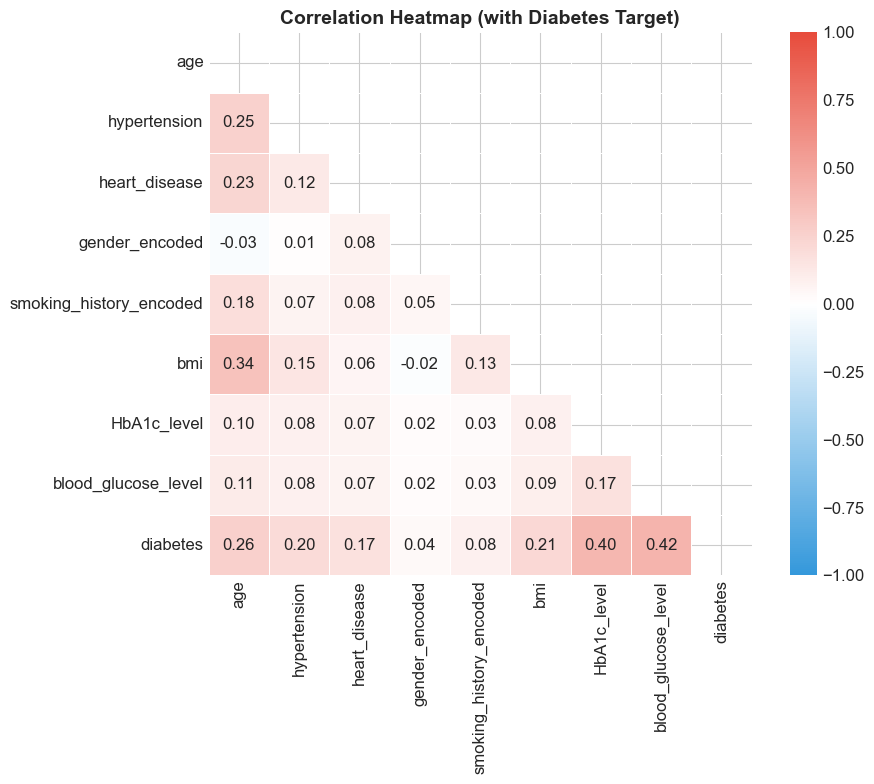


Correlation with diabetes target:
blood_glucose_level        0.419558
HbA1c_level                0.400660
age                        0.258008
bmi                        0.214357
hypertension               0.197823
heart_disease              0.171727
smoking_history_encoded    0.081765
gender_encoded             0.037666
Name: diabetes, dtype: float64


In [29]:
# Chart 21: Correlation heatmap including target
fig, ax = plt.subplots(figsize=(10, 8))
# Create ordinal mapping for smoking_history
smoking_map = {'never': 1, 'No Info': 1, 'not current': 2, 'former': 3, 'current': 4, 'ever': 5}
df_corr = df.copy()
df_corr['smoking_history_encoded'] = df_corr['smoking_history'].map(smoking_map)

# Create dummy for gender (Female=0, Male=1)
df_corr['gender_encoded'] = (df_corr['gender'] == 'Male').astype(int)

corr_cols = ['age', 'hypertension', 'heart_disease', 'gender_encoded', 
             'smoking_history_encoded', 'bmi', 'HbA1c_level', 'blood_glucose_level', 'diabetes']
corr_matrix = df_corr[corr_cols].corr()

mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
cmap = LinearSegmentedColormap.from_list('custom', ['#3498db', 'white', '#e74c3c'])
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap=cmap, center=0,
            square=True, linewidths=0.5, ax=ax, vmin=-1, vmax=1)
ax.set_title('Correlation Heatmap (with Diabetes Target)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../reports/figures/21_correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

print('\nCorrelation with diabetes target:')
print(corr_matrix['diabetes'].drop('diabetes').sort_values(ascending=False))

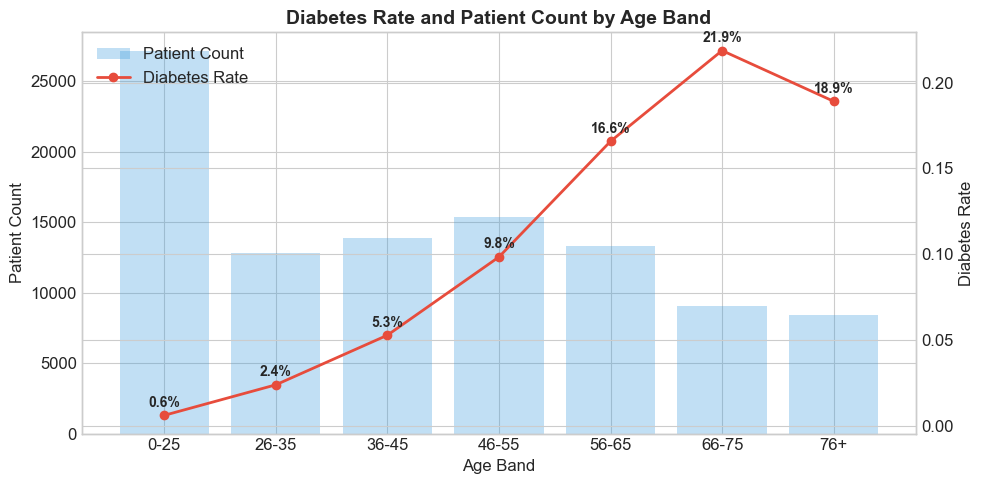

Chart 22: Diabetes rate increases significantly with age.


In [30]:
# Chart 22: Diabetes rate by age bands
fig, ax = plt.subplots(figsize=(10, 5))
df['age_band'] = pd.cut(df['age'], bins=[0, 25, 35, 45, 55, 65, 75, 100], 
                        labels=['0-25', '26-35', '36-45', '46-55', '56-65', '66-75', '76+'])
age_diabetes = df.groupby('age_band', observed=True)['diabetes'].agg(['mean', 'count'])
age_diabetes.columns = ['diabetes_rate', 'count']

ax2 = ax.twinx()
bars = ax.bar(range(len(age_diabetes)), age_diabetes['count'], alpha=0.3, color='#3498db', label='Patient Count')
line = ax2.plot(range(len(age_diabetes)), age_diabetes['diabetes_rate'], 
                color='#e74c3c', marker='o', linewidth=2, label='Diabetes Rate')

ax.set_title('Diabetes Rate and Patient Count by Age Band', fontsize=14, fontweight='bold')
ax.set_xlabel('Age Band', fontsize=12)
ax.set_ylabel('Patient Count', fontsize=12)
ax2.set_ylabel('Diabetes Rate', fontsize=12)
ax.set_xticks(range(len(age_diabetes)))
ax.set_xticklabels(age_diabetes.index)

for i, v in enumerate(age_diabetes['diabetes_rate']):
    ax2.text(i, v + 0.005, f'{v:.1%}', ha='center', fontweight='bold', fontsize=10)

lines1, labels1 = ax.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax.legend(lines1 + lines2, labels1 + labels2, loc='upper left')

plt.tight_layout()
plt.savefig('../reports/figures/22_diabetes_by_age_band.png', dpi=150, bbox_inches='tight')
plt.show()
print('Chart 22: Diabetes rate increases significantly with age.')

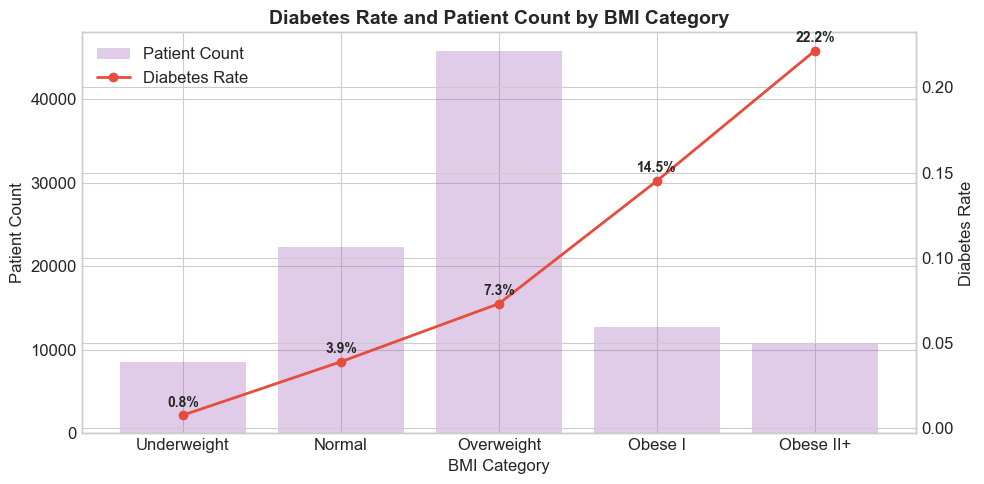

Chart 23: Higher BMI categories show increased diabetes rates.


In [31]:
# Chart 23: Diabetes rate by BMI category
fig, ax = plt.subplots(figsize=(10, 5))
df['bmi_category'] = pd.cut(df['bmi'], bins=[0, 18.5, 25, 30, 35, 100], 
                            labels=['Underweight', 'Normal', 'Overweight', 'Obese I', 'Obese II+'])
bmi_diabetes = df.groupby('bmi_category', observed=True)['diabetes'].agg(['mean', 'count'])
bmi_diabetes.columns = ['diabetes_rate', 'count']

ax2 = ax.twinx()
bars = ax.bar(range(len(bmi_diabetes)), bmi_diabetes['count'], alpha=0.3, color='#9b59b6', label='Patient Count')
line = ax2.plot(range(len(bmi_diabetes)), bmi_diabetes['diabetes_rate'], 
                color='#e74c3c', marker='o', linewidth=2, label='Diabetes Rate')

ax.set_title('Diabetes Rate and Patient Count by BMI Category', fontsize=14, fontweight='bold')
ax.set_xlabel('BMI Category', fontsize=12)
ax.set_ylabel('Patient Count', fontsize=12)
ax2.set_ylabel('Diabetes Rate', fontsize=12)
ax.set_xticks(range(len(bmi_diabetes)))
ax.set_xticklabels(bmi_diabetes.index)

for i, v in enumerate(bmi_diabetes['diabetes_rate']):
    ax2.text(i, v + 0.005, f'{v:.1%}', ha='center', fontweight='bold', fontsize=10)

lines1, labels1 = ax.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax.legend(lines1 + lines2, labels1 + labels2, loc='upper left')

plt.tight_layout()
plt.savefig('../reports/figures/23_diabetes_by_bmi_category.png', dpi=150, bbox_inches='tight')
plt.show()
print('Chart 23: Higher BMI categories show increased diabetes rates.')

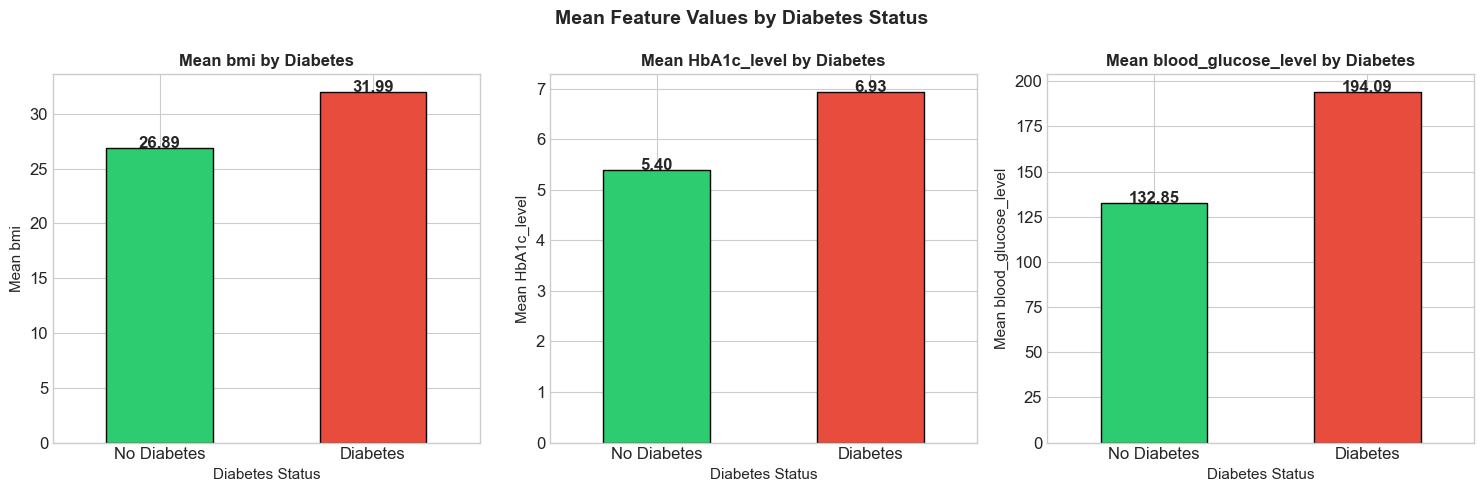

Chart 24: Diabetic patients show higher BMI, HbA1c, and blood glucose.


In [32]:
# Chart 24: Mean feature values by diabetes status
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

features_to_compare = ['bmi', 'HbA1c_level', 'blood_glucose_level']
for idx, col in enumerate(features_to_compare):
    means = df.groupby('diabetes')[col].mean()
    colors = ['#2ecc71', '#e74c3c']
    means.plot(kind='bar', color=colors, edgecolor='black', ax=axes[idx])
    axes[idx].set_title(f'Mean {col} by Diabetes', fontsize=12, fontweight='bold')
    axes[idx].set_xlabel('Diabetes Status', fontsize=11)
    axes[idx].set_ylabel(f'Mean {col}', fontsize=11)
    axes[idx].set_xticklabels(['No Diabetes', 'Diabetes'], rotation=0)
    for i, v in enumerate(means.values):
        axes[idx].text(i, v, f'{v:.2f}', ha='center', fontweight='bold')

plt.suptitle('Mean Feature Values by Diabetes Status', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../reports/figures/24_mean_features_by_diabetes.png', dpi=150, bbox_inches='tight')
plt.show()
print('Chart 24: Diabetic patients show higher BMI, HbA1c, and blood glucose.')

## 5. Key Insights & Feature Engineering Decisions

In [33]:
# Summary statistics by diabetes status
print('=== Summary Statistics by Diabetes Status ===')
summary = df.groupby('diabetes').describe()
print(summary.T.head(30))

=== Summary Statistics by Diabetes Status ===
diabetes                        0            1
age           count  91500.000000  8500.000000
              mean      40.115187    60.946588
              std       22.306005    14.549880
              min        0.080000     3.000000
              25%       22.000000    52.000000
              50%       40.000000    62.000000
              75%       57.000000    72.000000
              max       80.000000    80.000000
hypertension  count  91500.000000  8500.000000
              mean       0.058984     0.245647
              std        0.235595     0.430496
              min        0.000000     0.000000
              25%        0.000000     0.000000
              50%        0.000000     0.000000
              75%        0.000000     0.000000
              max        1.000000     1.000000
heart_disease count  91500.000000  8500.000000
              mean       0.029235     0.149059
              std        0.168465     0.356167
              

In [34]:
# Overall statistics
print('=== Key Dataset Statistics ===')
print(f'Total patients: {len(df):,}')
print(f'Diabetic patients: {(df["diabetes"] == 1).sum():,} ({df["diabetes"].mean()*100:.1f}%)')
print(f'Non-diabetic patients: {(df["diabetes"] == 0).sum():,} ({(1-df["diabetes"]).mean()*100:.1f}%)')
print(f'\nAge range: {df["age"].min():.0f} - {df["age"].max():.0f} years')
print(f'BMI range: {df["bmi"].min():.1f} - {df["bmi"].max():.1f} kg/m²')
print(f'HbA1c range: {df["HbA1c_level"].min():.1f} - {df["HbA1c_level"].max():.1f} %')
print(f'Glucose range: {df["blood_glucose_level"].min():.0f} - {df["blood_glucose_level"].max():.0f} mg/dL')

=== Key Dataset Statistics ===
Total patients: 100,000
Diabetic patients: 8,500 (8.5%)
Non-diabetic patients: 91,500 (91.5%)

Age range: 0 - 80 years
BMI range: 10.0 - 95.7 kg/m²
HbA1c range: 3.5 - 9.0 %
Glucose range: 80 - 300 mg/dL


In [35]:
# Clean up temporary columns
df.drop(['age_band', 'bmi_category'], axis=1, inplace=True)
print('Temporary columns dropped.')

Temporary columns dropped.


## Summary of Findings

### Data Quality Issues
1. **No missing values** in the dataset
2. **Duplicate rows** detected (handle in preprocessing)
3. **"No Info" category** in smoking_history (~35% of data) - needs handling
4. **Outliers** detected in BMI and other numerical variables
5. **Class imbalance**: Only ~8.5% of patients have diabetes

### Key Diabetes Risk Factors Identified
1. **HbA1c_level** - Strongest correlation with diabetes (higher values = higher risk)
2. **blood_glucose_level** - Strong positive correlation with diabetes
3. **age** - Older patients have significantly higher diabetes rates
4. **bmi** - Higher BMI associated with increased diabetes risk
5. **hypertension** - Patients with hypertension show ~2x higher diabetes rate
6. **heart_disease** - Patients with heart disease show ~2x higher diabetes rate

### Candidate Features for Modeling
- **age** - continuous, strong predictor
- **bmi** - continuous, moderate predictor
- **HbA1c_level** - continuous, very strong predictor
- **blood_glucose_level** - continuous, very strong predictor
- **hypertension** - binary, moderate predictor
- **heart_disease** - binary, moderate predictor
- **gender** - nominal categorical, weak predictor
- **smoking_history** - ordinal categorical, weak predictor

### Feature Engineering Decisions
1. **smoking_history**: 
   - Ordinal mapping: never(1) → not current(2) → former(3) → current(4) → ever(5)
   - "No Info" treated as 'never' (1) or imputed separately
   - Alternative: one-hot encoding with N-1 dummies

2. **gender**: 
   - Nominal categorical - use N-1 dummy encoding (drop one column)

3. **Outliers in BMI**:
   - Consider capping at 99th percentile or using robust scaling

4. **Class imbalance**:
   - Consider SMOTE, class weights, or appropriate threshold selection

5. **Potential data leakage**:
   - HbA1c_level and blood_glucose_level are clinical measurements directly related to diabetes diagnosis
   - These are valid predictors but should be noted as post-hoc measurements in interpretation

## Data Quality Issues Summary

| Issue | Details | Recommendation |
|-------|---------|----------------|
| Missing values | None detected | No imputation needed |
| Duplicates | Present | Remove during preprocessing |
| "No Info" smoking | ~35% of records | Map to 'never' or create separate category |
| Outliers in BMI | Some extreme values | Consider capping or robust scaling |
| Class imbalance | ~8.5% positive | Use class weights or appropriate threshold |
| "Other" gender | 18 records | Consider dropping or merging with dominant class |